# Electron Diffraction on Graphite

Computational model for an electron-diffraction tube.

An electron is accelerated through a potential difference $U$, acquiring a de Broglie wavelength $\lambda(U)$. It is diffracted by the graphite crystal and produces concentric rings on a fluorescent screen at distance $L$ from the diffraction point.

This notebook covers:
1. The de Broglie wavelength as a function of accelerating voltage.
2. The Bragg scattering angles for graphite.
3. The resulting ring radii on the screen.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants (SI)
h    = 6.62607015e-34   # Planck constant, J*s
m_e  = 9.1093837015e-31 # electron mass, kg
e    = 1.602176634e-19  # elementary charge, C
c    = 2.99792458e8     # speed of light, m/s

# Geometry of the tube
L = 150e-3   # distance from diffraction point to screen, m

# Graphite interplanar spacings (m)
d10 = 0.213e-9   # (10) planes
d11 = 0.123e-9   # (11) planes

## 1. De Broglie wavelength vs accelerating voltage

Non-relativistic, the electron momentum is $p = \sqrt{2 m_e e U}$, so

$$\lambda = \frac{h}{\sqrt{2 m_e e U}}.$$

A convenient engineering form is $\lambda\,[\text{Å}] = 12.264/\sqrt{U\,[\text{V}]}$.

The relativistic correction (included below for reference) is only ~0.15% at 3 kV:

$$\lambda_\text{rel} = \frac{h}{\sqrt{2 m_e e U \left(1 + \dfrac{eU}{2 m_e c^2}\right)}}.$$

In [2]:
def wavelength(U, relativistic=False):
    """De Broglie wavelength of an electron accelerated through voltage U (volts).
    Returns wavelength in meters."""
    if relativistic:
        return h / np.sqrt(2 * m_e * e * U * (1 + e * U / (2 * m_e * c**2)))
    return h / np.sqrt(2 * m_e * e * U)

# Quick check at 3 kV
U0 = 3000.0
print(f"lambda (non-rel) = {wavelength(U0)*1e12:.3f} pm = {wavelength(U0)*1e10:.4f} A")
print(f"lambda (rel)     = {wavelength(U0, True)*1e12:.3f} pm")
print(f"engineering form = {12.264/np.sqrt(U0):.4f} A")

lambda (non-rel) = 22.391 pm = 0.2239 A
lambda (rel)     = 22.359 pm
engineering form = 0.2239 A


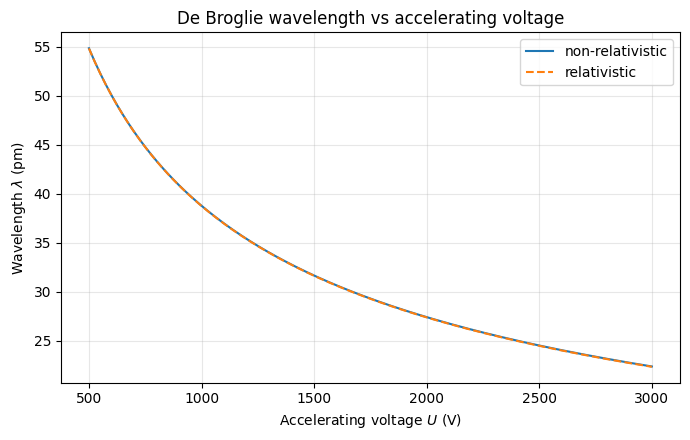

In [8]:
U = np.linspace(500, 3000, 200)

plt.figure(figsize=(7, 4.5))
plt.plot(U, wavelength(U)*1e12, label='non-relativistic')
plt.plot(U, wavelength(U, True)*1e12, '--', label='relativistic')
plt.xlabel('Accelerating voltage $U$ (V)')
plt.ylabel('Wavelength $\\lambda$ (pm)')
plt.title('De Broglie wavelength vs accelerating voltage')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 2. Bragg scattering angles for graphite

The Bragg condition for first-order reflection from planes of spacing $d$ is

$$2 d \sin\theta = \lambda \quad\Rightarrow\quad \theta = \arcsin\!\left(\frac{\lambda}{2d}\right).$$

The diffracted beam is deflected by $2\theta$, so on a flat screen the ring radius is

$$r = L\,\tan(2\theta).$$

In [9]:
def bragg_angle(lam, d):
    """Bragg angle theta (rad) for wavelength lam and spacing d."""
    return np.arcsin(lam / (2 * d))

def ring_radius(lam, d, L=L):
    """Ring radius on a flat screen (m) for wavelength lam and spacing d."""
    theta = bragg_angle(lam, d)
    return L * np.tan(2 * theta)

# Scattering angles at the reference voltage
lam0 = wavelength(U0)
for name, d in [('(10)', d10), ('(11)', d11)]:
    th = bragg_angle(lam0, d)
    print(f"{name}: theta = {np.degrees(th):.3f} deg, "
          f"2*theta = {np.degrees(2*th):.3f} deg, "
          f"ring radius = {ring_radius(lam0, d)*1e3:.2f} mm, "
          f"diameter = {2*ring_radius(lam0, d)*1e3:.2f} mm")

(10): theta = 3.013 deg, 2*theta = 6.026 deg, ring radius = 15.83 mm, diameter = 31.67 mm
(11): theta = 5.222 deg, 2*theta = 10.445 deg, ring radius = 27.65 mm, diameter = 55.30 mm


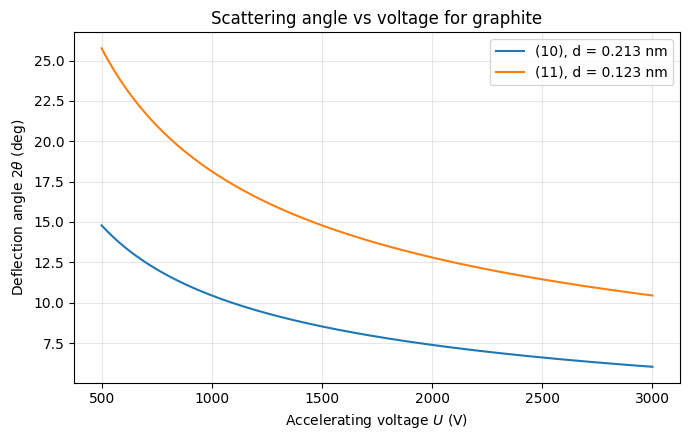

In [5]:
# Scattering angle 2*theta as a function of voltage for both plane families
lam = wavelength(U)

plt.figure(figsize=(7, 4.5))
plt.plot(U, np.degrees(2*bragg_angle(lam, d10)), label='(10), d = 0.213 nm')
plt.plot(U, np.degrees(2*bragg_angle(lam, d11)), label='(11), d = 0.123 nm')
plt.xlabel('Accelerating voltage $U$ (V)')
plt.ylabel('Deflection angle $2\\theta$ (deg)')
plt.title('Scattering angle vs voltage for graphite')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 3. Ring diameters vs voltage

The directly observable quantity is the ring diameter on the screen, $D = 2r$. Lower voltage means a longer wavelength, larger Bragg angle, and wider rings.

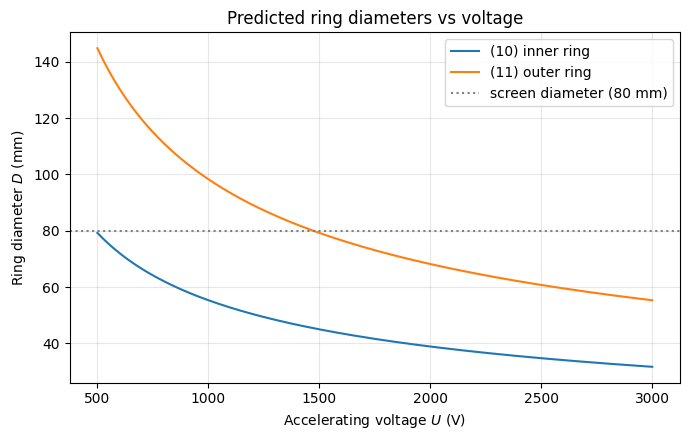

In [6]:
plt.figure(figsize=(7, 4.5))
plt.plot(U, 2*ring_radius(lam, d10)*1e3, label='(10) inner ring')
plt.plot(U, 2*ring_radius(lam, d11)*1e3, label='(11) outer ring')
plt.axhline(80, color='gray', ls=':', label='screen diameter (80 mm)')
plt.xlabel('Accelerating voltage $U$ (V)')
plt.ylabel('Ring diameter $D$ (mm)')
plt.title('Predicted ring diameters vs voltage')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# Table of predicted ring diameters at selected voltages
print(f"{'U (kV)':>8} | {'D(10) mm':>10} | {'D(11) mm':>10}")
print('-' * 34)
for Uk in [2.0, 2.3, 2.5, 3.0, 3.5, 4.0]:
    lamk = wavelength(Uk*1e3)
    D10 = 2*ring_radius(lamk, d10)*1e3
    D11 = 2*ring_radius(lamk, d11)*1e3
    print(f"{Uk:>8.1f} | {D10:>10.2f} | {D11:>10.2f}")

  U (kV) |   D(10) mm |   D(11) mm
----------------------------------
     2.0 |      38.87 |      68.16
     2.3 |      36.21 |      63.41
     2.5 |      34.72 |      60.74
     3.0 |      31.67 |      55.30
     3.5 |      29.30 |      51.11
     4.0 |      27.40 |      47.74


# Voltage 3kV


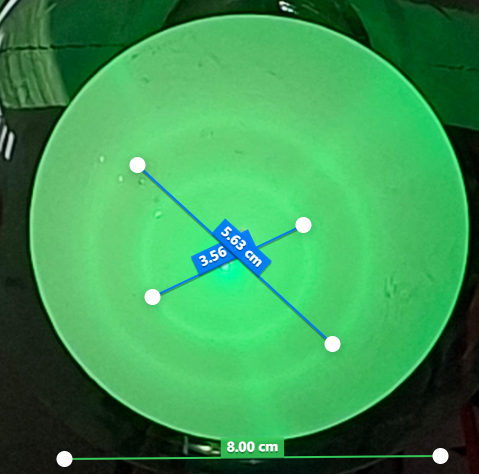

# Voltage less 3kV (about 2.5 kV)


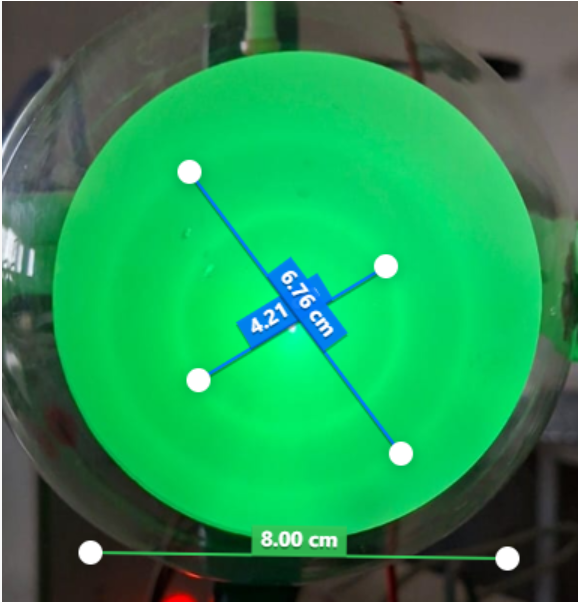